# 探索性数据分析 (EDA)

::: {.callout-note}
## 导言

数据拿到手以后，不能马上进入回归或预测模型。更稳妥的做法是先做一轮 **探索性数据分析 (EDA)**：检查变量分布、识别极端值、理解变量之间的关系，并判断图形结论是否稳定。

本章衔接「数据获取」与「数据清洗」。前者解决「数据从哪里来」，后者解决「数据如何整理成可分析样本」。本章关心的是中间环节：拿到数据以后，在建模之前，应该先看什么、怎么看、如何把发现转化为一张能进入报告或论文的图。
:::

::: {.callout-note}
## 本章要点

- **问题驱动的 EDA 工作流**：每一张图都应回答一个具体问题。
- **探索性图形与解释性图形**：草图用来发现，精修图用来表达结论。
- **单变量分布**：均值、中位数、标准差、MAD、直方图、箱型图。
- **两变量关系**：协方差、相关系数、散点图、对数坐标和分仓散点图。
- **时序数据可视化**：折线图、滚动统计量、双轴图与高亮策略。
- **多变量关系**：相关热力图、分面图和交互式图形。
- **可比性与稳定性**：好的 EDA 结论不应依赖某一个偶然的作图选择。
:::

本章使用两类数据：

- 模拟上市公司财务面板。优点是可复现，不依赖外部接口。
- 沪深 300 日度行情。为保证讲义可复现，默认使用模拟行情数据；若需要读取真实行情，可在数据构造代码中将 `USE_AKSHARE` 改为 `True`。


## 环境准备


In [2]:
# ── 环境准备 ─────────────────────────────────────────────────────
# 依赖库：
# pip install pandas numpy matplotlib seaborn scipy plotly akshare

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

# 中文字体设置：不同系统的字体名称可能不同，下面按顺序尝试常见字体
matplotlib.rcParams["font.sans-serif"] = [
    "SimHei", "Microsoft YaHei", "PingFang SC",
    "Arial Unicode MS", "Noto Sans CJK SC", "DejaVu Sans"
]
matplotlib.rcParams["axes.unicode_minus"] = False

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 15)

OUTPUT = "output"
DATA_RAW = "data_raw"

for folder in [OUTPUT, DATA_RAW]:
    os.makedirs(folder, exist_ok=True)

RNG = np.random.default_rng(42)

print("环境就绪。")


环境就绪。


In [3]:
# ── 构造贯穿全章的数据集 ─────────────────────────────────────────
# 本章使用两类数据：
# (A) 模拟上市公司财务面板：可复现，不依赖外部接口；
# (B) 沪深 300 日度行情：默认使用模拟数据，避免联网失败影响课堂运行。
#
# 若希望读取 AKShare 真实行情，将 USE_AKSHARE 改为 True 即可。
# 需要说明的是，在线接口可能因网络、限流或字段变化而失败，
# 因此课堂讲义默认采用可复现的模拟行情数据。

USE_AKSHARE = False

# ── (A) 模拟上市公司财务面板：500 家公司，2015-2023 年 ─────────────
np.random.seed(2024)

FIRMS = 500
YEARS = list(range(2015, 2024))

firm_ids = [f"firm_{i:04d}" for i in range(FIRMS)]
industries = np.random.choice(
    ["制造业", "金融业", "零售业", "科技业", "房地产"],
    FIRMS
)
soe_flag = np.random.binomial(1, 0.35, FIRMS)

rows = []
for i, firm_id in enumerate(firm_ids):
    # 设定一个公司层面的基础盈利能力。
    # 这里让民企的平均 ROA 略高于国企，便于后文演示组间比较。
    base_roa = np.random.normal(0.05 if soe_flag[i] else 0.07, 0.03)

    for year in YEARS:
        leverage = np.clip(
            np.random.beta(2, 5) + 0.05 * soe_flag[i],
            0.05,
            0.95
        )
        roa = base_roa + np.random.normal(0, 0.02)
        size = np.random.normal(23 + 0.5 * soe_flag[i], 1.2)

        rows.append({
            "firm": firm_id,
            "year": year,
            "industry": industries[i],
            "soe": soe_flag[i],
            "ROA": roa,
            "Leverage": leverage,
            "Size": size
        })

df_fin = pd.DataFrame(rows)

print(f"财务面板：{df_fin.shape[0]} 行，{df_fin.shape[1]} 列。")
print(f"样本结构：{FIRMS} 家公司 × {len(YEARS)} 年。")

# ── (B) 沪深 300 日度行情：AKShare 或模拟数据 ─────────────────────
if USE_AKSHARE:
    try:
        import akshare as ak

        hs300 = ak.stock_zh_index_daily(symbol="sh000300")
        hs300["date"] = pd.to_datetime(hs300["date"])
        hs300 = hs300.sort_values("date")

        cutoff = pd.Timestamp("2020-01-01")
        hs300 = hs300[hs300["date"] >= cutoff].copy()
        hs300["ret"] = np.log(hs300["close"] / hs300["close"].shift(1))
        hs300 = hs300.dropna(subset=["ret"])

        DATA_SOURCE = "AKShare 获取的沪深 300 实际数据"

    except Exception as err:
        print(f"AKShare 读取失败，改用模拟行情数据。错误信息：{err}")
        USE_AKSHARE = False

if not USE_AKSHARE:
    # 模拟行情数据只用于演示可视化流程，不应解释为真实市场结论。
    dates = pd.date_range("2020-01-02", "2025-12-31", freq="B")
    rets = RNG.normal(0.0003, 0.012, len(dates))

    hs300 = pd.DataFrame({"date": dates, "ret": rets})
    hs300["close"] = 4000 * np.cumprod(1 + rets)
    hs300["volume"] = RNG.lognormal(22, 0.5, len(dates))

    # 为 K 线图构造一组 OHLC 字段。真实行情数据中通常已包含这些字段。
    open_noise = RNG.normal(0, 0.002, len(dates))
    high_noise = np.abs(RNG.normal(0.006, 0.002, len(dates)))
    low_noise = np.abs(RNG.normal(0.006, 0.002, len(dates)))

    hs300["open"] = hs300["close"].shift(1).fillna(hs300["close"].iloc[0]) * (1 + open_noise)
    hs300["high"] = hs300[["open", "close"]].max(axis=1) * (1 + high_noise)
    hs300["low"] = hs300[["open", "close"]].min(axis=1) * (1 - low_noise)

    DATA_SOURCE = "模拟数据"

print(f"行情数据：{len(hs300)} 行。")
print(f"数据来源：{DATA_SOURCE}")

hs300.tail(3)


财务面板：4500 行，7 列。
样本结构：500 家公司 × 9 年。
行情数据：1565 行。
数据来源：模拟数据


,date,ret,close,volume,open,high,low
1562,2025-12-29,-0.0095,3447.6135,4406936869.3176,3482.5230,3503.5042,3425.8673
1563,2025-12-30,-0.0135,3401.2017,2493436705.0672,3442.4895,3455.4719,3369.9962
1564,2025-12-31,-0.0110,3363.8475,4312799054.2800,3400.3785,3414.0916,3350.8100


## 问题驱动的 EDA 工作流

面对一份新数据，常见错误是试图一次性画出所有图。数据集往往有几十个变量，如果每一对变量都画散点图，很快就会得到成百上千张没有主题的图。

更有效的做法是采用 **问题 → 图形 → 答案 → 新问题** 的迭代过程。也就是说，先问一个清楚的问题，再选择最合适的图形；图形给出初步答案以后，再决定下一步该检查什么。

在金融研究中，驱动 EDA 的问题通常来自三类：

| 问题类型 | 示例 | 常用图形 |
|----------|------|----------|
| 描述型 | 沪深 300 近 5 年的收益率分布是什么形状？ | 直方图、密度图、箱型图 |
| 比较型 | 国企和民企的 ROA 分布有何差异？ | 分组箱型图、小提琴图、分面图 |
| 关系型 | 公司规模与杠杆率是否存在系统性关系？ | 散点图、趋势线、相关系数 |

本章后面的每个例子都会尽量对应一个具体问题，而不是单纯展示某个绘图函数的用法。

![探索性数据分析的工作流](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/data_eda_viz_fig01_eda_workflow.png){fig-align="center" width="100%"}

这张图给出了本章 EDA 的基本路径。实际分析时，不必机械地从左到右完成所有步骤，但至少应形成一个习惯：先确认数据结构和变量类型，再检查数据质量，之后再进入分布、关系、分组和时序图形。这样可以避免在数据尚未理解清楚时，过早进入建模或解释。


### 选择合适的图形类型

图形类型通常由两个因素决定：变量个数和变量类型。下面这张图可以作为选图的快速导航，后面的表格则把常见变量结构和推荐图形进一步对应起来。

![常用统计图形选择图](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/data_eda_viz_fig02_chart_selection_map.png){fig-align="center" width="100%"}

选图的关键不是图形是否复杂，而是图形能否回答当前问题。比如，想看一个变量的分布，直方图和箱型图通常比散点图更合适；想看两个连续变量的关系，散点图、拟合线或分仓散点图更直接；想比较不同组之间的差异，则应优先考虑分组箱型图、小提琴图或分面图。


| 变量结构 | 典型问题 | 推荐图形 |
|----------|----------|----------|
| 1 个数值型变量 | 收益率分布是什么形状？ | 直方图、箱型图、核密度图 |
| 1 个数值型变量 + 时间 | 股价如何随时间变化？ | 折线图 |
| 2 个数值型变量 | ROA 与 Size 的关系如何？ | 散点图、趋势线、分仓散点图 |
| 1 个数值型变量 + 1 个类别型变量 | 不同行业 ROA 有何差异？ | 分组箱型图、分面图 |
| 多个数值型变量 | 控制变量之间是否高度相关？ | 相关矩阵、热力图 |
| 数值型变量 + 地理位置 | 各地区上市公司数量如何分布？ | 地图、分级设色图 |

::: {.callout-note}
## 图形不是唯一答案

有时候，一个设计良好的表格比图形更清楚。例如，「2023 年借款利率最高的 10 家公司」更适合用表格展示。EDA 的目标是看清数据，而不是为了画图而画图。
:::


## 探索性图形与解释性图形

Yu and Barter (2023) 区分了 EDA 的两个阶段。这个区分在金融数据分析中很实用。

**探索性图形**用于自己看数据。它可以粗糙，可以没有完整标注，只要能帮助分析者快速发现异常、模式和下一步问题即可。

**解释性图形**用于给别人看。它应当有明确主题句、清楚坐标轴、必要参照线和适度标注。它不是把所有信息都放进去，而是帮助读者快速理解一个结论。

::: {.callout-important}
## 一张解释性图形只讲一件事

图形最常见的问题不是信息太少，而是信息太多。如果一张图需要读者反复寻找重点，它更像探索性草图，而不是解释性展示图。论文、报告和课堂展示中的图，应尽量对应一句清楚的结论。
:::

下面用「沪深 300 日度收益率的分布」演示同一个问题如何从草图变为精修图。


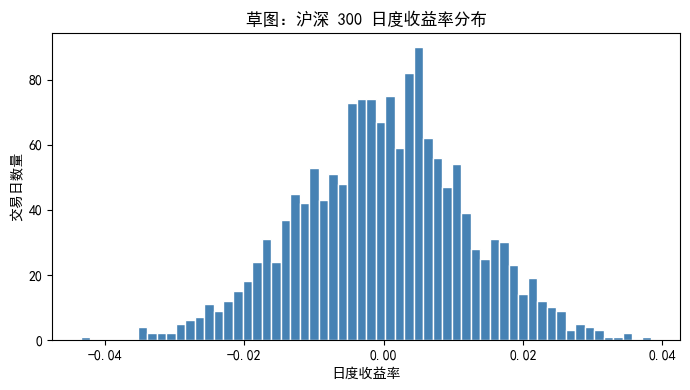

In [ ]:
# ── 探索性草图：快速看清分布形态 ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(
    hs300["ret"],
    bins=60,
    color="darkblue",
    edgecolor="white"
)

ax.set_title("草图：沪深 300 日度收益率分布")
ax.set_xlabel("日度收益率")
ax.set_ylabel("交易日数量")

plt.tight_layout()
plt.show()

# 草图只需要帮助自己判断：分布是否偏斜？尾部是否很厚？
# 下一步可以继续追问：极端日有多少？实际分布与正态分布差异有多大？


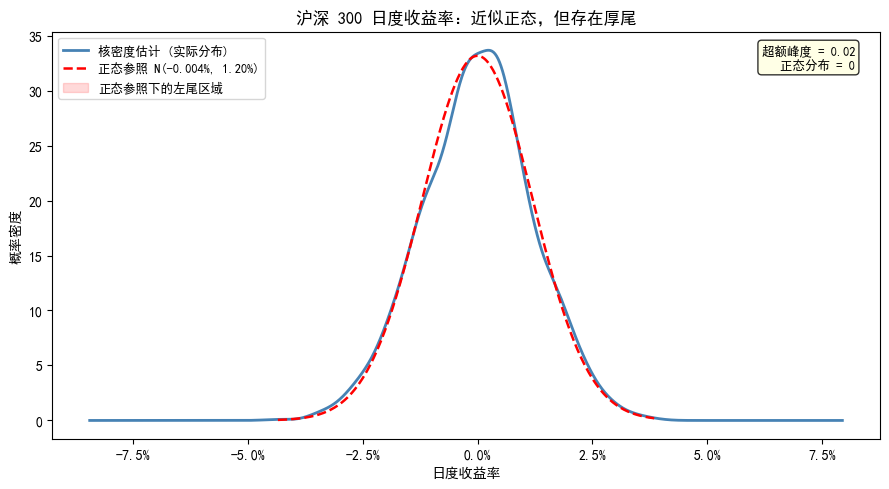

超额峰度 = 0.0215。若该值大于 0，说明实际分布比正态分布有更厚的尾部。


In [ ]:
# ── 解释性图形：围绕一个明确结论组织图形元素 ─────────────────────
# 主题句：沪深 300 日度收益率近似正态，但尾部比正态分布更厚。

mu = hs300["ret"].mean()
sigma = hs300["ret"].std()

x_norm = np.linspace(hs300["ret"].min(), hs300["ret"].max(), 300)
y_norm = stats.norm.pdf(x_norm, mu, sigma)

fig, ax = plt.subplots(figsize=(9, 5))

# 实际分布：核密度估计
hs300["ret"].plot.kde(
    ax=ax,
    color="darkblue",
    lw=2,
    label="核密度估计 (实际分布)"
)

# 参照分布：均值和标准差相同的正态分布
ax.plot(
    x_norm,
    y_norm,
    linestyle="--",
    color="red",
    lw=1.8,
    label=f"正态参照 N({mu * 100:.3f}%, {sigma * 100:.2f}%)"
)

# 标注极端下跌日：低于均值 4 个标准差
threshold = mu - 4 * sigma
extreme = hs300[hs300["ret"] < threshold]

for _, row in extreme.iterrows():
    ax.axvline(row["ret"], color="orange", lw=1, alpha=0.7)

if len(extreme) > 0:
    ax.axvline(
        extreme["ret"].iloc[0],
        color="orange",
        lw=1,
        label=f"极端下跌日 (< -4σ, 共 {len(extreme)} 天)"
    )

# 标出正态分布预测的左尾区域
ax.fill_between(
    x_norm,
    np.zeros_like(y_norm),
    y_norm,
    where=x_norm < threshold,
    alpha=0.15,
    color="red",
    label="正态参照下的左尾区域"
)

kurt = hs300["ret"].kurtosis()  # pandas 返回超额峰度，正态分布为 0

ax.text(
    0.97,
    0.97,
    f"超额峰度 = {kurt:.2f}\n正态分布 = 0",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8)
)

ax.set_xlabel("日度收益率")
ax.set_ylabel("概率密度")
ax.set_title("沪深 300 日度收益率：近似正态，但存在厚尾")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))

plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_ret_dist_explanatory.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"超额峰度 = {kurt:.4f}。若该值大于 0，说明实际分布比正态分布有更厚的尾部。")


比较草图和精修图，可以看到精修图并不是简单地「更好看」，而是增加了若干帮助读者理解结论的元素。

| 元素 | 草图 | 精修图 |
|------|------|--------|
| 标题 | 描述变量 | 直接给出主题句 |
| 参照系 | 没有参照 | 叠加正态参照分布 |
| 注意力引导 | 读者自己寻找重点 | 标出极端下跌日和左尾区域 |
| 定量说明 | 没有数值注释 | 给出超额峰度 |
| 坐标轴 | 默认小数格式 | 收益率按百分比显示 |

这些调整都服务于同一个目标：让读者快速理解图形要表达的结论。


## 单变量分析：典型值、分散程度与分布形状

### 均值与中位数

描述一个变量时，最常见的问题是：一个「典型」观测值大概是多少？**均值 (mean)** 和 **中位数 (median)** 是两个最常用的答案。

$$\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_{i}$$

中位数是将所有观测值从小到大排序后位于中间位置的值。如果 $n$ 为偶数，则通常取中间两个值的均值。

两者的关键区别在于：均值对极端值敏感，中位数更稳健。金融数据中，这个区别经常影响判断。

- 计算市场平均日收益率时，如果样本中有一个极端上涨日，均值会被明显拉高，中位数变化很小。
- 计算上市公司平均总资产时，少数巨型公司会让均值远高于大多数公司的资产规模，中位数更接近「典型公司」。


In [6]:
# ── 极端值对均值和中位数的影响 ─────────────────────────────────
ret = hs300["ret"].copy()

mean_orig = ret.mean()
median_orig = ret.median()

# 人工加入一个极端值，模拟异常交易日。
ret_shock = ret.copy()
ret_shock.iloc[0] = 0.30

mean_shock = ret_shock.mean()
median_shock = ret_shock.median()

print("极端值对均值和中位数的影响：")
print("                 原始数据        加入 +30% 极端日")
print(
    f"  均值：   {mean_orig * 100:+.5f}%    →    {mean_shock * 100:+.5f}%  "
    f"(变化 {(mean_shock - mean_orig) * 100:+.5f}%)"
)
print(
    f"  中位数： {median_orig * 100:+.5f}%    →    {median_shock * 100:+.5f}%  "
    f"(变化 {(median_shock - median_orig) * 100:+.6f}%)"
)

ratio = abs(mean_shock - mean_orig) / max(abs(median_shock - median_orig), 1e-10)

print()
print(f"样本量 N = {len(ret)}。")
print(f"在这个例子中，均值变化大约是中位数变化的 {ratio:.0f} 倍。")


极端值对均值和中位数的影响：
                 原始数据        加入 +30% 极端日
  均值：   -0.00383%    →    +0.01509%  (变化 +0.01892%)
  中位数： +0.02770%    →    +0.02770%  (变化 +0.000000%)

样本量 N = 1565。
在这个例子中，均值变化大约是中位数变化的 1891651 倍。


In [ ]:
# ── 年度 ROA 的描述统计 ─────────────────────────────────────────
# 问题：不同年份，上市公司的盈利能力 (ROA) 有何变化？

roa_stats = (
    df_fin
    .groupby("year")["ROA"]
    .agg(
        N="count",
        Mean="mean",
        Median="median",
        Std="std",
        Q25=lambda x: x.quantile(0.25),
        Q75=lambda x: x.quantile(0.75),
        Min="min",
        Max="max"
    )
    .round(4)
)

print("各年度 ROA 描述统计：")
print(roa_stats.to_string())

print()
print("观察：多数年份的均值略高于中位数，说明少数高盈利公司会抬高均值。")


各年度 ROA 描述统计：
        N   Mean  Median    Std    Q25    Q75     Min    Max
year                                                        
2015  500 0.0602  0.0601 0.0378 0.0366 0.0844 -0.0709 0.1765
2016  500 0.0587  0.0594 0.0360 0.0330 0.0841 -0.0498 0.1680
2017  500 0.0599  0.0624 0.0377 0.0343 0.0827 -0.0981 0.1673
2018  500 0.0599  0.0616 0.0374 0.0329 0.0838 -0.0693 0.1975
2019  500 0.0604  0.0599 0.0368 0.0357 0.0844 -0.0455 0.1899
2020  500 0.0611  0.0608 0.0352 0.0368 0.0855 -0.0365 0.1577
2021  500 0.0623  0.0632 0.0368 0.0406 0.0864 -0.1045 0.1818
2022  500 0.0579  0.0578 0.0358 0.0333 0.0826 -0.0589 0.1712
2023  500 0.0597  0.0601 0.0383 0.0332 0.0860 -0.1002 0.1713

观察：多数年份的均值略高于中位数，说明少数高盈利公司会抬高均值。


### 方差、标准差与 MAD

知道典型值以后，下一步要问：数据有多分散？**方差 (variance)** 和 **标准差 (standard deviation)** 度量数值相对均值的离散程度。

$$\operatorname{Var}(x)=\frac{1}{n}\sum_{i=1}^{n}(x_{i}-\bar{x})^{2}$$

$$\operatorname{SD}(x)=\sqrt{\operatorname{Var}(x)}$$

方差的量纲是原始变量的平方，因此金融实践中更常用标准差。例如，日度收益率标准差可以理解为日度波动率，乘以 $\sqrt{252}$ 后得到常用的年化波动率。

当数据中存在极端值时，可以同时报告 **中位数绝对偏差 (median absolute deviation, MAD)**。标准定义是：

$$\operatorname{MAD}(x)=\operatorname{median}\left(|x_{i}-\operatorname{median}(x)|\right)$$

这里需要说明的是，MAD 不是以均值为中心，而是以中位数为中心，因此比标准差更不容易被极端值拉动。


In [8]:
# ── 收益率分散程度：SD、MAD 与 IQR ─────────────────────────────
# 问题：用不同指标度量沪深 300 波动时，结果有多大差异？

ret = hs300["ret"]

sd_daily = ret.std()
mad_daily = stats.median_abs_deviation(ret, scale=1.0)
iqr_daily = ret.quantile(0.75) - ret.quantile(0.25)
kurt = ret.kurtosis()

print("日度收益率的分散程度：")
print(f"  标准差 (SD)       ：{sd_daily * 100:.4f}%  年化 = {sd_daily * 100 * np.sqrt(252):.2f}%")
print(f"  MAD               ：{mad_daily * 100:.4f}%  年化 = {mad_daily * 100 * np.sqrt(252):.2f}%")
print(f"  四分位距 (IQR)    ：{iqr_daily * 100:.4f}%")
print(f"  超额峰度          ：{kurt:.4f}")

print()
print("本例中，MAD 小于 SD，说明标准差受尾部观测影响更明显。")
print("在金融收益率数据中，SD 适合度量总体波动，MAD 适合描述典型交易日的波动。")


日度收益率的分散程度：
  标准差 (SD)       ：1.2030%  年化 = 19.10%
  MAD               ：0.7827%  年化 = 12.42%
  四分位距 (IQR)    ：1.5770%
  超额峰度          ：0.0215

本例中，MAD 小于 SD，说明标准差受尾部观测影响更明显。
在金融收益率数据中，SD 适合度量总体波动，MAD 适合描述典型交易日的波动。


### 直方图与箱型图

均值、中位数、标准差都是单个数字，它们无法完整呈现分布形态。例如，变量是否偏斜、是否双峰、尾部是否很厚，都需要通过图形来判断。

**直方图**把变量取值划分为若干区间，用柱子的高度表示每个区间内的观测数量。它适合观察单变量分布形态。

**箱型图**用分位数概括分布。箱子的上下边界分别是 $Q_{1}$ 和 $Q_{3}$，箱内横线是中位数，箱体高度为四分位距 $IQR=Q_{3}-Q_{1}$。常见画法中，须线延伸到 $Q_{1}-1.5IQR$ 和 $Q_{3}+1.5IQR$ 范围内的最远观测值，超出该范围的点被标为疑似离群值。

::: {.callout-warning}
## 直方图的 bin 宽度会影响视觉结论

同一份数据，bin 太宽可能掩盖结构，bin 太窄又可能把随机噪声画成局部模式。探索阶段应多试几种合理的 bin 宽度，确认主要结论是否稳定。
:::


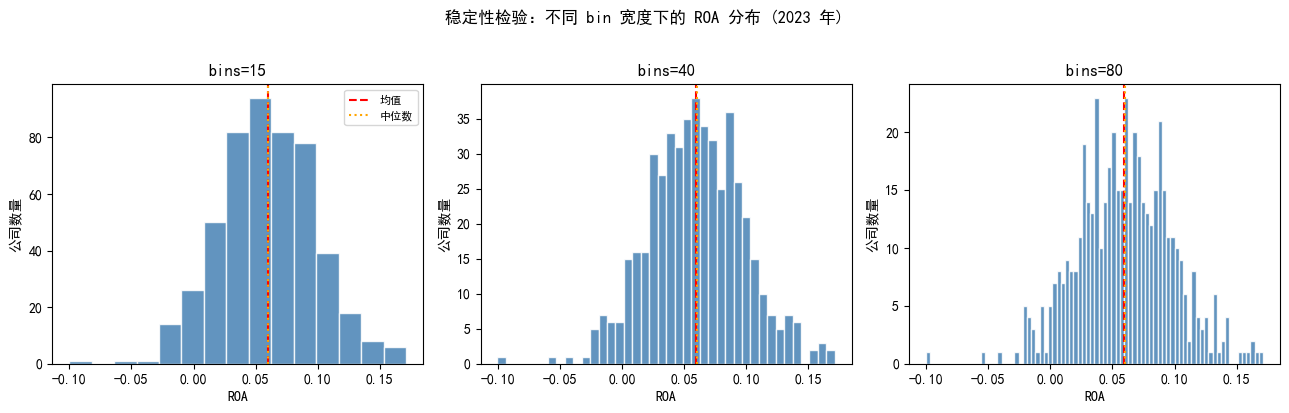

三种 bin 宽度下，ROA 分布的主要结论基本一致。
ROA 均值 = 0.0597，中位数 = 0.0601。


In [ ]:
# ── 直方图的 bin 稳定性检验 ─────────────────────────────────────
# 问题：上市公司 ROA 的分布形态是什么？结论对 bin 宽度是否敏感？

roa_2023 = df_fin.loc[df_fin["year"] == 2023, "ROA"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

settings = [
    (15, "bins=15"),
    (40, "bins=40"),
    (80, "bins=80")
]

for ax, (bins, label) in zip(axes, settings):
    ax.hist(
        roa_2023,
        bins=bins,
        color="darkblue",
        edgecolor="white",
        alpha=0.85
    )
    ax.axvline(roa_2023.mean(), color="red", lw=1.5, linestyle="--", label="均值")
    ax.axvline(roa_2023.median(), color="orange", lw=1.5, linestyle=":", label="中位数")
    ax.set_title(label)
    ax.set_xlabel("ROA")
    ax.set_ylabel("公司数量")

    if ax is axes[0]:
        ax.legend(fontsize=8)

plt.suptitle("稳定性检验：不同 bin 宽度下的 ROA 分布 (2023 年)", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_hist_stability.png", dpi=150, bbox_inches="tight")
plt.show()

print("三种 bin 宽度下，ROA 分布的主要结论基本一致。")
print(f"ROA 均值 = {roa_2023.mean():.4f}，中位数 = {roa_2023.median():.4f}。")


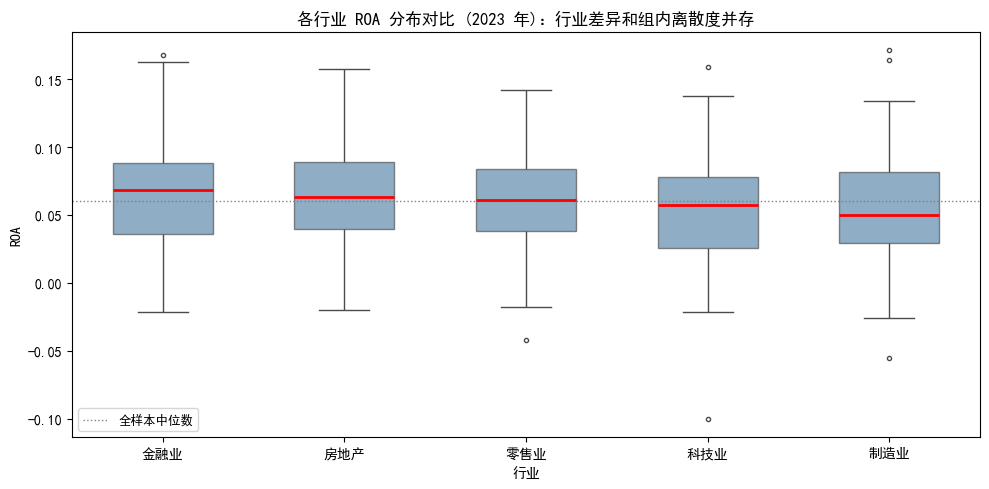

In [ ]:
# ── 箱型图：比较行业 ROA 分布 ───────────────────────────────────
# 问题：不同行业的盈利能力 (ROA) 有何差异？

roa_2023_df = df_fin[df_fin["year"] == 2023].copy()

# 按行业 ROA 中位数从高到低排序，避免默认字母顺序干扰比较。
industry_order = (
    roa_2023_df
    .groupby("industry")["ROA"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=roa_2023_df,
    x="industry",
    y="ROA",
    order=industry_order,
    color="darkblue",
    width=0.55,
    fliersize=3,
    boxprops={"alpha": 0.65},
    medianprops={"color": "red", "linewidth": 2},
    ax=ax
)

ax.axhline(
    roa_2023_df["ROA"].median(),
    color="gray",
    lw=1,
    linestyle=":",
    label="全样本中位数"
)

ax.set_title("各行业 ROA 分布对比 (2023 年)：行业差异和组内离散度并存")
ax.set_xlabel("行业")
ax.set_ylabel("ROA")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_boxplot_industry.png", dpi=150, bbox_inches="tight")
plt.show()


## 两变量关系：协方差、相关系数与散点图

### 协方差与 Pearson 相关系数

探索两个数值变量之间的关系，常见起点是计算线性关联强度。

协方差定义为：

$$\operatorname{Cov}(x,y)=\frac{1}{n}\sum_{i=1}^{n}(x_{i}-\bar{x})(y_{i}-\bar{y})$$

协方差的符号反映关系方向，但数值大小取决于变量量纲，不便于跨变量比较。

Pearson 相关系数把协方差除以两个变量的标准差，使结果落在 $[-1,1]$ 之间：

$$\operatorname{Corr}(x,y)=\frac{\operatorname{Cov}(x,y)}{\operatorname{SD}(x)\operatorname{SD}(y)}$$

- $\operatorname{Corr}=1$：完全正线性关系。
- $\operatorname{Corr}=0$：无线性关系，但不等于没有关系。
- $\operatorname{Corr}=-1$：完全负线性关系。

::: {.callout-warning}
## 相关系数只捕捉线性关系

相关系数为 0 不等于两个变量无关。如果 $y=x^{2}$ 且 $x$ 关于 0 对称分布，相关系数可能接近 0，但二者显然存在确定的非线性关系。因此，散点图是相关系数的必要补充。
:::


In [11]:
# ── 协方差与相关系数的数值演示 ─────────────────────────────────
# 问题：公司规模 (Size) 与杠杆率 (Leverage) 是否相关？

sub = (
    df_fin
    .loc[df_fin["year"] == 2023, ["Size", "Leverage", "ROA"]]
    .dropna()
)

x = sub["Size"].to_numpy()
y = sub["Leverage"].to_numpy()

# 手动计算。这里使用 n 作为分母，因此协方差会与 pandas 默认的 n-1 分母略有差异。
cov_manual = np.mean((x - x.mean()) * (y - y.mean()))
corr_manual = cov_manual / (x.std(ddof=0) * y.std(ddof=0))

print("Size vs Leverage (2023 年截面)：")
print(f"  协方差 (手动，分母为 n)      = {cov_manual:.6f}")
print(f"  协方差 (pandas，分母为 n-1) = {sub['Size'].cov(sub['Leverage']):.6f}")
print(f"  相关系数 (手动)             = {corr_manual:.4f}")
print(f"  相关系数 (pandas)           = {sub['Size'].corr(sub['Leverage']):.4f}")

print()
print("三变量相关矩阵：")
print(sub.corr().round(4).to_string())


Size vs Leverage (2023 年截面)：
  协方差 (手动，分母为 n)      = -0.002898
  协方差 (pandas，分母为 n-1) = -0.002904
  相关系数 (手动)             = -0.0155
  相关系数 (pandas)           = -0.0155

三变量相关矩阵：
            Size  Leverage     ROA
Size      1.0000   -0.0155  0.0342
Leverage -0.0155    1.0000 -0.0361
ROA       0.0342   -0.0361  1.0000


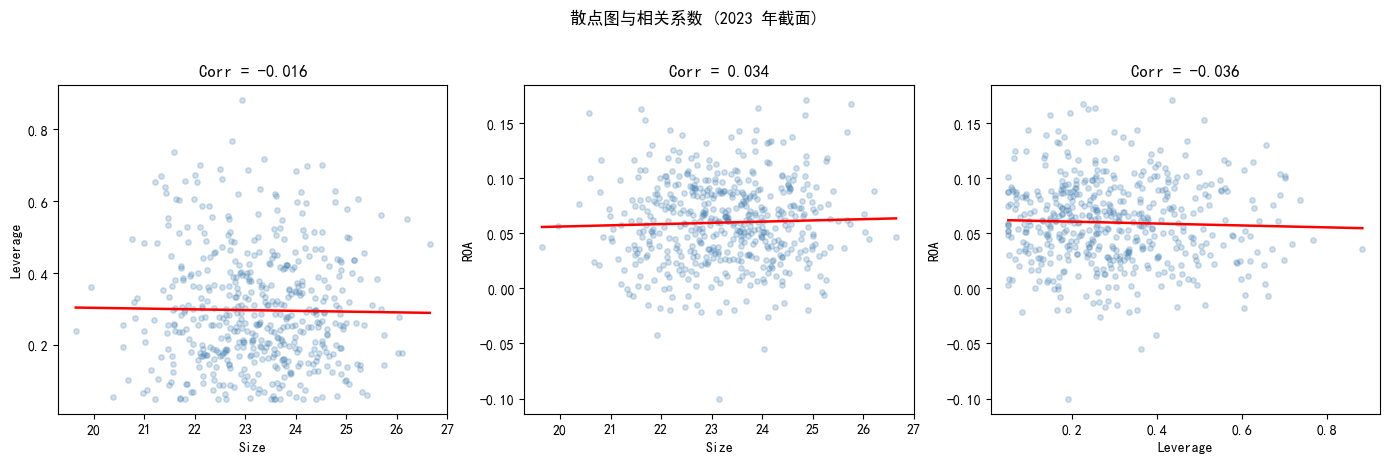

In [ ]:
# ── 散点图：用图形检查相关系数 ─────────────────────────────────
# 核心原则：相关系数是散点图中线性趋势强弱的数值摘要，不能替代散点图。

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

pairs = [
    ("Size", "Leverage"),
    ("Size", "ROA"),
    ("Leverage", "ROA")
]

for ax, (xvar, yvar) in zip(axes, pairs):
    ax.scatter(
        sub[xvar],
        sub[yvar],
        alpha=0.25,
        s=15,
        color="darkblue"
    )

    # 添加线性趋势线。
    slope, intercept, r_value, p_value, std_err = stats.linregress(sub[xvar], sub[yvar])
    x_line = np.linspace(sub[xvar].min(), sub[xvar].max(), 100)

    ax.plot(
        x_line,
        slope * x_line + intercept,
        color="red",
        lw=1.8
    )

    corr = sub[xvar].corr(sub[yvar])

    ax.set_xlabel(xvar)
    ax.set_ylabel(yvar)
    ax.set_title(f"Corr = {corr:.3f}")

plt.suptitle("散点图与相关系数 (2023 年截面)", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_scatter_corr.png", dpi=150, bbox_inches="tight")
plt.show()


### 对数坐标：处理高度右偏数据

金融数据中有很多高度右偏变量，例如总资产、成交金额、市值、交易量。大多数观测集中在较低区间，少数巨型公司或高成交日取值极大。在普通坐标轴上，很多点会挤在图的左下角，散点图几乎看不出结构。

**对数坐标轴 (log scale)** 把轴刻度改为数量级等距，例如 1、10、100、1000。这样可以把密集的低值区域展开，把极大的高值压缩回来，使右偏变量的关系更容易观察。

::: {.callout-warning}
## 对数变换不能直接用于 0 或负数

如果变量包含 0 或负数，不能直接取对数。常见处理方式包括：

- 使用 $\log(x+1)$，适用于非负变量。
- 只保留正值子样本，并在图注中说明筛选条件。
- 对 0 值单独标记，不把它们强行放入对数坐标。
:::


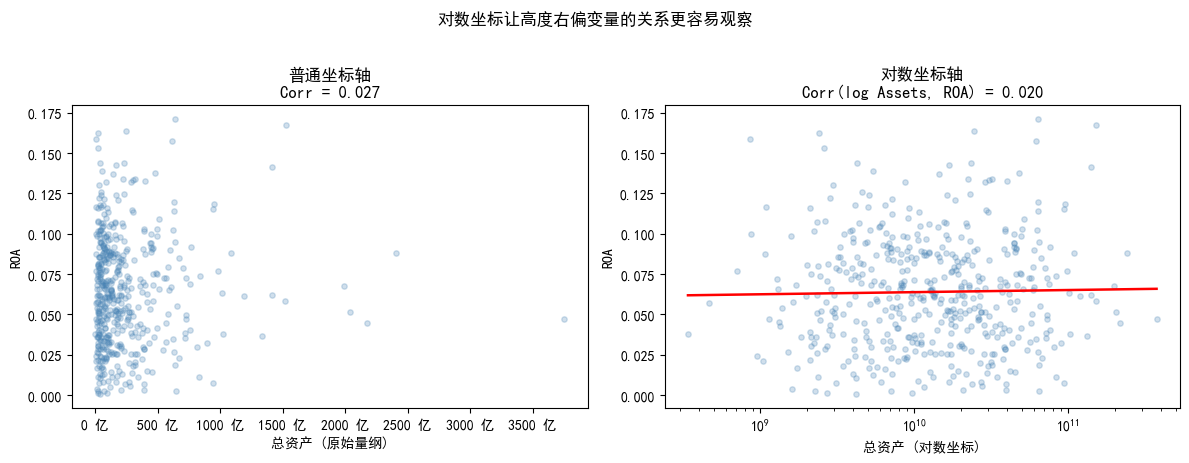

In [ ]:
# ── 对数坐标的效果：以公司规模为例 ─────────────────────────────
# 本章模拟数据中的 Size 已经是 ln(总资产)，这里先用 exp(Size) 还原为原始规模。

sub_pos = sub[sub["ROA"] > 0].copy()
sub_pos["Assets"] = np.exp(sub_pos["Size"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 普通坐标。
axes[0].scatter(
    sub_pos["Assets"],
    sub_pos["ROA"],
    alpha=0.25,
    s=15,
    color="darkblue"
)
axes[0].set_xlabel("总资产 (原始量纲)")
axes[0].set_ylabel("ROA")
axes[0].set_title(f"普通坐标轴\nCorr = {sub_pos['Assets'].corr(sub_pos['ROA']):.3f}")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, pos: f"{x / 1e8:.0f} 亿")
)

# 对数坐标。
axes[1].scatter(
    sub_pos["Assets"],
    sub_pos["ROA"],
    alpha=0.25,
    s=15,
    color="darkblue"
)
axes[1].set_xscale("log")
axes[1].set_xlabel("总资产 (对数坐标)")
axes[1].set_ylabel("ROA")

log_corr = np.log(sub_pos["Assets"]).corr(sub_pos["ROA"])
axes[1].set_title(f"对数坐标轴\nCorr(log Assets, ROA) = {log_corr:.3f}")

# 趋势线：在线性化后的 log(Assets) 上估计，再映射回原始坐标。
slope, intercept, *_ = stats.linregress(np.log(sub_pos["Assets"]), sub_pos["ROA"])
x_log = np.linspace(
    np.log(sub_pos["Assets"].min()),
    np.log(sub_pos["Assets"].max()),
    100
)
axes[1].plot(
    np.exp(x_log),
    slope * x_log + intercept,
    color="red",
    lw=1.8
)

plt.suptitle("对数坐标让高度右偏变量的关系更容易观察", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_log_scale.png", dpi=150, bbox_inches="tight")
plt.show()


### 分仓散点图

样本量很大时，普通散点图容易变成一团墨迹。即使真实关系很清楚，读者也可能只看到密集点云和少数离群点。

**分仓散点图 (binned scatter plot)** 的做法是：先按横轴变量把样本分成若干个区间，再计算每个区间内横轴变量和纵轴变量的均值，最后画出这些区间均值。它牺牲了部分个体层面的细节，但更容易呈现总体趋势。



![分仓散点图的基本思路](https://fig-lianxh.oss-cn-shenzhen.aliyuncs.com/data_eda_viz_fig03_binned_scatter_logic.png){fig-align="center" width="100%"}

分仓散点图的直觉很简单：先保留横轴变量的排序信息，再把拥挤的原始点云压缩为若干组均值点。它不适合替代正式回归，但很适合在 EDA 阶段快速判断变量之间是否存在单调关系、非线性关系或局部异常。


下面构造一个模拟例子。真实关系是 $y=x^{2}+\varepsilon$，也就是 U 型关系；同时加入少数离群点和大量观测，使普通散点图难以读出主线。


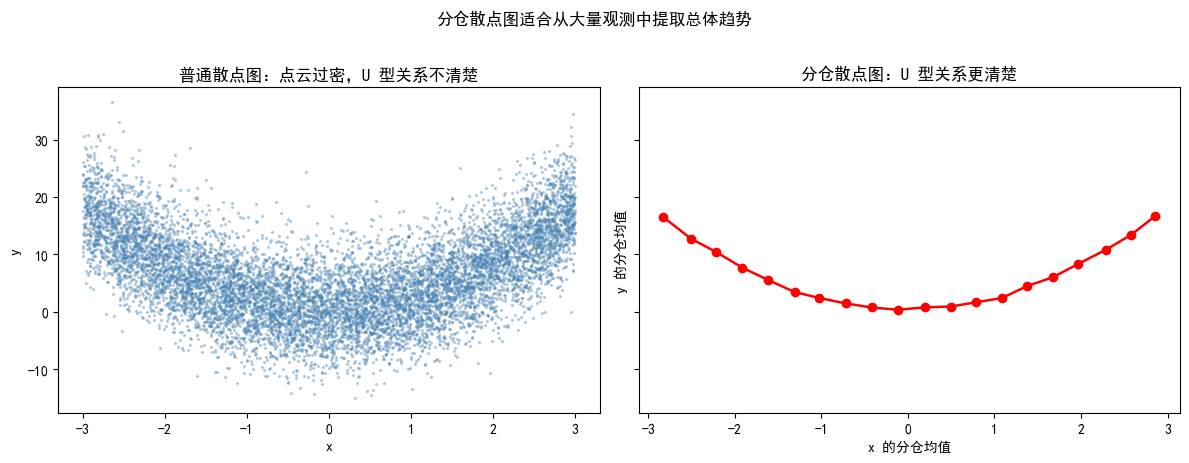

原始样本量：10,000。
分仓后点数：20。每个点代表一个 x 区间内的均值。


In [ ]:
# ── 分仓散点图：在大量观测中识别非线性关系 ─────────────────────
# 问题：当普通散点图过度拥挤时，如何看清 x 与 y 的总体关系？

n_obs = 10000

rng = np.random.default_rng(2026)
x = rng.uniform(-3, 3, n_obs)
eps = rng.normal(0, 5, n_obs)
y = 2 * x**2 + eps

# 加入少数离群值，模拟异常观测。
outlier_idx = rng.choice(n_obs, size=400, replace=False)
y[outlier_idx] += rng.normal(8, 2, size=len(outlier_idx))

df_bin = pd.DataFrame({"x": x, "y": y})

# 分成 20 个分位数区间，并计算每个区间内 x 和 y 的均值。
df_bin["bin"] = pd.qcut(df_bin["x"], q=20, duplicates="drop")
binned = (
    df_bin
    .groupby("bin", observed=True)
    .agg(x_mean=("x", "mean"), y_mean=("y", "mean"), n=("y", "size"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

# 左图：普通散点图。为了展示拥挤效果，使用全部观测并设置较低透明度。
axes[0].scatter(
    df_bin["x"],
    df_bin["y"],
    s=2,
    alpha=0.3,
    color="darkblue"
)
axes[0].set_title("普通散点图：点云过密，U 型关系不清楚")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# 右图：分仓散点图。
axes[1].plot(
    binned["x_mean"],
    binned["y_mean"],
    marker="o",
    lw=1.8,
    color="red"
)
axes[1].set_title("分仓散点图：U 型关系更清楚")
axes[1].set_xlabel("x 的分仓均值")
axes[1].set_ylabel("y 的分仓均值")

plt.suptitle("分仓散点图适合从大量观测中提取总体趋势", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_binned_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"原始样本量：{len(df_bin):,}。")
print(f"分仓后点数：{len(binned)}。每个点代表一个 x 区间内的均值。")


## 时序数据的金融可视化

金融数据最常见的维度是时间。时序图不仅要呈现水平高低，还要呈现趋势、波动、阶段变化和异常时期。因此，时序图的设计原则与截面分布图有所不同。

### 折线图的设计原则

时序折线图是金融报告中最常见的图形。几个细节尤其容易影响解读：

- **$y$ 轴是否从 0 开始**。如果变量是数量或金额，通常应考虑从 0 开始；如果变量是收益率、估值倍数或指数净值，从 0 开始可能会压缩变化。
- **多条折线的颜色数量**。颜色过多会削弱可读性。类别较多时，可以采用「高亮一条，其余置灰」的策略。
- **双轴图的使用**。两个变量量纲不同，例如指数净值和成交量，可以使用双轴图。但双轴图不应被用来暗示相关关系或因果关系，因为轴范围的选择会改变视觉印象。


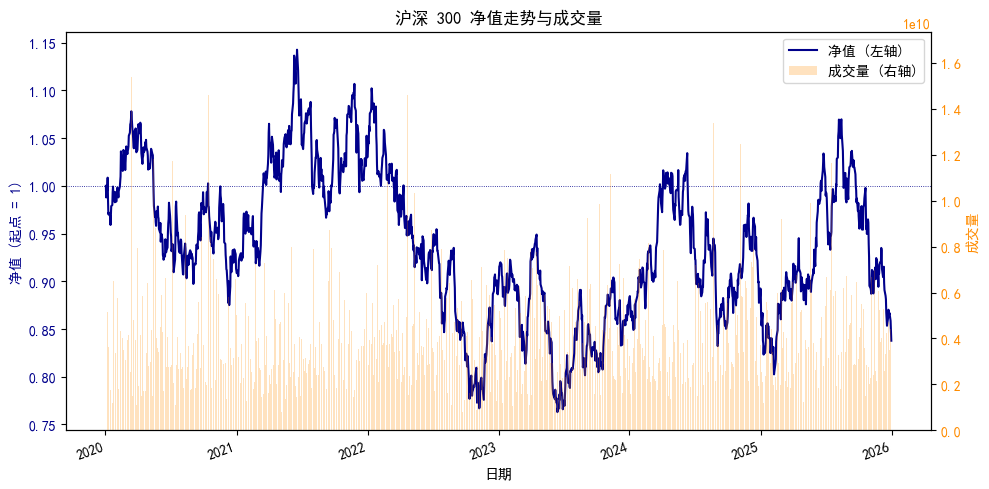

In [40]:
# ── 沪深 300 净值走势与成交量：双轴图 ───────────────────────────
# 目的：展示同一时间轴上的两个不同量纲变量。
# 说明：双轴图适合展示，不适合直接据此判断相关或因果关系。

fig, ax1 = plt.subplots(figsize=(10, 5))

hs300_plot = hs300.copy()
hs300_plot["nav"] = hs300_plot["close"] / hs300_plot["close"].iloc[0]

# 主轴：指数净值。
ax1.plot(
    hs300_plot["date"],
    hs300_plot["nav"],
    color="darkblue",
    lw=1.5,
    label="净值 (左轴)"
)
ax1.set_ylabel("净值 (起点 = 1)", color="darkblue")
ax1.tick_params(axis="y", labelcolor="darkblue")
ax1.axhline(1, color="darkblue", lw=0.6, linestyle=":")

# 副轴：成交量。如果数据中没有 volume 字段，则只展示净值。
if "volume" in hs300_plot.columns:
    ax2 = ax1.twinx()

    ax2.bar(
        hs300_plot["date"],
        hs300_plot["volume"],
        color="darkorange",
        alpha=0.25,
        width=1,
        label="成交量 (右轴)"
    )
    ax2.set_ylabel("成交量", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)
else:
    ax1.legend(loc="upper right", fontsize=10)

ax1.set_title("沪深 300 净值走势与成交量")
ax1.set_xlabel("日期")

fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_nav_volume.png", dpi=150, bbox_inches="tight")
plt.show()


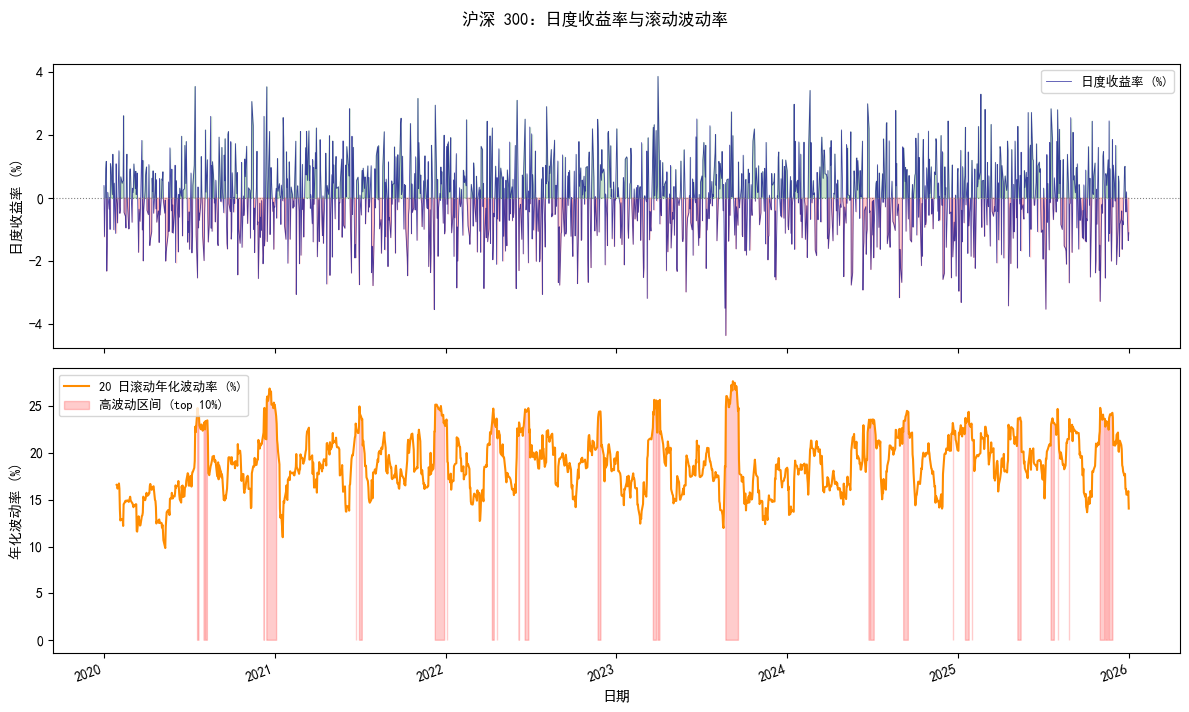

In [41]:
# ── 滚动统计量：捕捉时变波动率 ─────────────────────────────────
# 问题：波动率随时间如何变化？高波动时期集中在哪里？

hs_roll = hs300.copy().set_index("date")
hs_roll["roll_mean"] = hs_roll["ret"].rolling(20).mean()
hs_roll["roll_std"] = hs_roll["ret"].rolling(20).std()
hs_roll["roll_std_ann"] = hs_roll["roll_std"] * np.sqrt(252)

x_dates = hs_roll.index.to_pydatetime()
ret_pct = (hs_roll["ret"] * 100).to_numpy()
vol_pct = (hs_roll["roll_std_ann"] * 100).to_numpy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# 上图：日度收益率。
ax1.plot(
    x_dates,
    ret_pct,
    color="darkblue",
    lw=0.6,
    alpha=0.7,
    label="日度收益率 (%)"
)
ax1.axhline(0, color="gray", lw=0.8, linestyle=":")
ax1.fill_between(
    x_dates,
    ret_pct,
    0,
    where=ret_pct > 0,
    color="green",
    alpha=0.2
)
ax1.fill_between(
    x_dates,
    ret_pct,
    0,
    where=ret_pct < 0,
    color="red",
    alpha=0.2
)
ax1.set_ylabel("日度收益率 (%)")
ax1.legend(fontsize=9, loc="upper right")

# 下图：20 日滚动年化波动率。
high_vol = hs_roll["roll_std_ann"] > hs_roll["roll_std_ann"].quantile(0.9)
high_vol = high_vol.fillna(False).to_numpy()

ax2.plot(
    x_dates,
    vol_pct,
    color="darkorange",
    lw=1.5,
    label="20 日滚动年化波动率 (%)"
)
ax2.fill_between(
    x_dates,
    vol_pct,
    where=high_vol,
    color="red",
    alpha=0.2,
    label="高波动区间 (top 10%)"
)
ax2.set_ylabel("年化波动率 (%)")
ax2.set_xlabel("日期")
ax2.legend(fontsize=9)

plt.suptitle("沪深 300：日度收益率与滚动波动率", y=1.01)
fig.autofmt_xdate(rotation=20)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_rolling_vol.png", dpi=150, bbox_inches="tight")
plt.show()


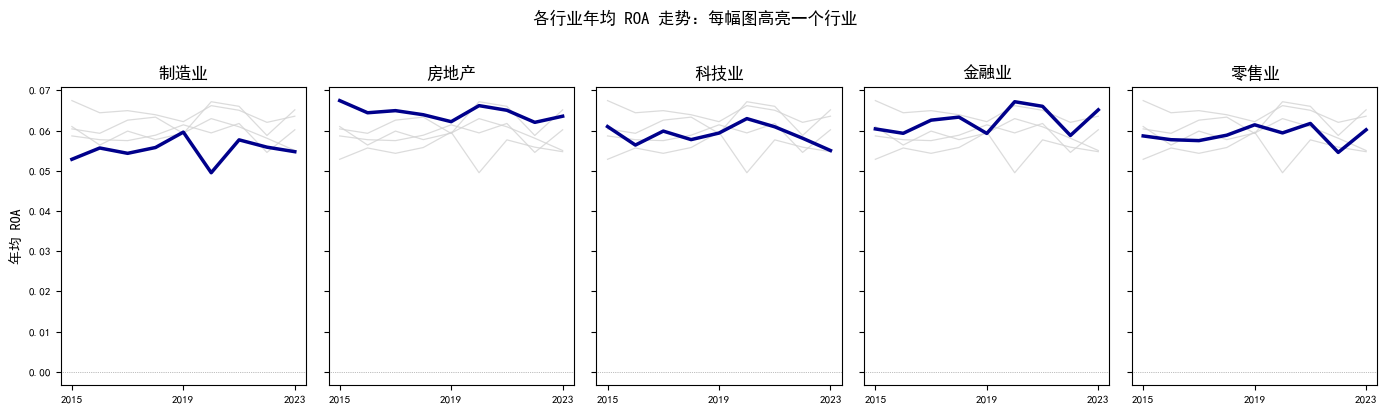

In [42]:
# ── 多条折线中的高亮策略 ───────────────────────────────────────
# 问题：各行业公司的年均 ROA 如何随时间变化？

ind_year_roa = (
    df_fin
    .groupby(["industry", "year"])["ROA"]
    .mean()
    .reset_index()
)

all_industries = ind_year_roa["industry"].unique()

fig, axes = plt.subplots(
    1,
    len(all_industries),
    figsize=(14, 4),
    sharey=True
)

for ax, highlight_ind in zip(axes, all_industries):
    for industry, group in ind_year_roa.groupby("industry"):
        if industry == highlight_ind:
            ax.plot(
                group["year"],
                group["ROA"],
                color="darkblue",
                lw=2.5,
                zorder=5,
                label=industry
            )
        else:
            ax.plot(
                group["year"],
                group["ROA"],
                color="lightgray",
                lw=0.9,
                alpha=0.8,
                zorder=1
            )

    ax.set_title(highlight_ind)
    ax.set_xticks([2015, 2019, 2023])
    ax.tick_params(labelsize=8)
    ax.axhline(0, color="gray", lw=0.5, linestyle=":")

axes[0].set_ylabel("年均 ROA")

plt.suptitle("各行业年均 ROA 走势：每幅图高亮一个行业", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_multiline_highlight.png", dpi=150, bbox_inches="tight")
plt.show()


## 多变量关系：热力图与分面图

### 相关热力图

当变量数量超过两个时，逐一查看变量对会很低效。相关热力图把相关矩阵转化为颜色编码，适合快速识别高度相关的变量对。

在金融研究中，热力图常用于以下场景：

- 检查控制变量之间是否存在严重多重共线性。
- 了解不同因子收益率之间的相关结构。
- 构造资产组合前，观察资产收益率相关矩阵。


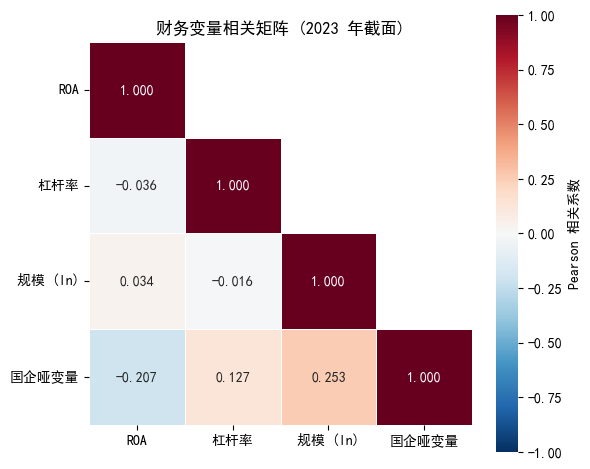

本例中没有相关系数绝对值大于 0.5 的变量对。


In [43]:
# ── 财务变量相关热力图 ─────────────────────────────────────────
# 问题：财务变量之间是否存在明显相关性？是否存在多重共线性风险？

vars_for_corr = ["ROA", "Leverage", "Size", "soe"]
corr_mat = df_fin.loc[df_fin["year"] == 2023, vars_for_corr].corr()

fig, ax = plt.subplots(figsize=(6, 5))

# 只显示下三角，避免上下三角重复。
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

sns.heatmap(
    corr_mat,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    mask=mask,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson 相关系数"},
    ax=ax
)

labels = {
    "ROA": "ROA",
    "Leverage": "杠杆率",
    "Size": "规模 (ln)",
    "soe": "国企哑变量"
}

ax.set_xticklabels(
    [labels.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
    fontsize=10
)
ax.set_yticklabels(
    [labels.get(t.get_text(), t.get_text()) for t in ax.get_yticklabels()],
    fontsize=10,
    rotation=0
)
ax.set_title("财务变量相关矩阵 (2023 年截面)")

plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

high_corr = [
    (c1, c2, corr_mat.loc[c1, c2])
    for i, c1 in enumerate(vars_for_corr)
    for c2 in vars_for_corr[(i + 1):]
    if abs(corr_mat.loc[c1, c2]) > 0.5
]

if high_corr:
    print("相关系数绝对值大于 0.5 的变量对：")
    for c1, c2, corr_value in high_corr:
        print(f"  {c1} × {c2}: {corr_value:.3f}")
else:
    print("本例中没有相关系数绝对值大于 0.5 的变量对。")


### 分面图

分面图 (facet grid / small multiple) 适合处理「同一个指标在多个组之间如何变化」的问题。它把每个组放在一个独立面板中，并尽量共享坐标轴范围，使跨组比较更直观。

在金融研究中，分面图常见于：

- 每个行业一个面板，展示行业 ROA 随时间变化。
- 每个投资组合一个面板，展示组合收益率走势。
- 每个政策组一个面板，展示事件窗口内的收益率变化。


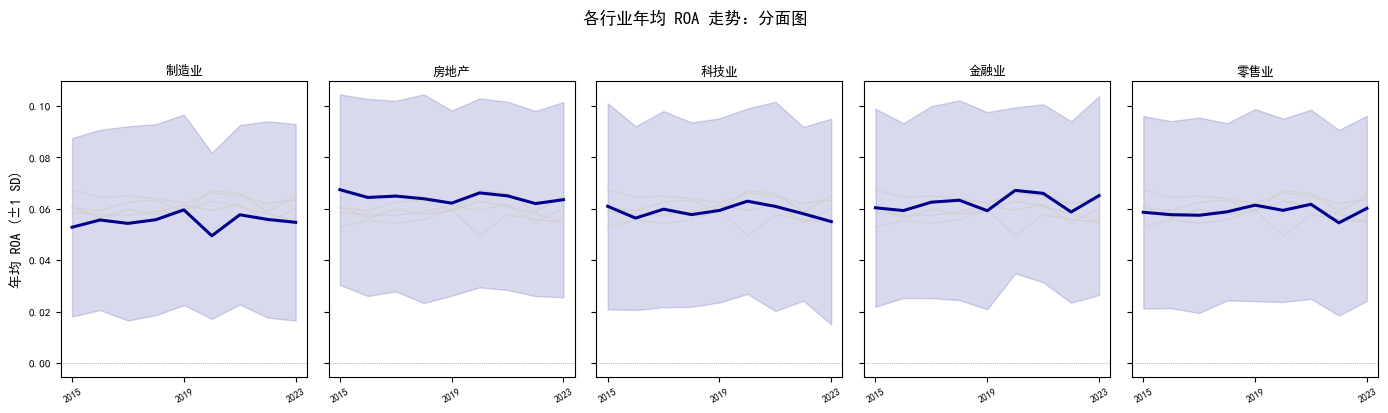

In [44]:
# ── 分面图：各行业 ROA 的时序轨迹 ─────────────────────────────
# 思路：每个面板高亮一个行业，其他行业作为灰色背景线。

ind_year_roa_full = (
    df_fin
    .groupby(["industry", "year"])["ROA"]
    .agg(["mean", "std"])
    .reset_index()
)

all_industries = ind_year_roa_full["industry"].unique()

fig, axes = plt.subplots(
    1,
    len(all_industries),
    figsize=(14, 4),
    sharey=True
)

for ax, this_industry in zip(axes, all_industries):
    # 灰色背景线：其他行业。
    for other_industry, group in ind_year_roa_full.groupby("industry"):
        if other_industry != this_industry:
            ax.plot(
                group["year"].to_numpy(),
                group["mean"].to_numpy(),
                color="#D0D0D0",
                lw=1,
                alpha=0.8
            )

    # 当前行业：高亮均值，并给出 ±1 个标准差的范围。
    this_group = ind_year_roa_full[ind_year_roa_full["industry"] == this_industry]

    x_year = this_group["year"].to_numpy()
    y_mean = this_group["mean"].to_numpy()
    y_std = this_group["std"].to_numpy()

    ax.plot(x_year, y_mean, color="darkblue", lw=2.2, zorder=5)
    ax.fill_between(
        x_year,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.15,
        color="darkblue"
    )

    ax.axhline(0, color="gray", lw=0.5, linestyle=":")
    ax.set_title(this_industry, fontsize=9, pad=4)
    ax.set_xticks([2015, 2019, 2023])
    ax.set_xticklabels(["2015", "2019", "2023"], fontsize=7, rotation=30)
    ax.tick_params(axis="y", labelsize=8)

axes[0].set_ylabel("年均 ROA (±1 SD)")

plt.suptitle("各行业年均 ROA 走势：分面图", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_facet_industry_roa.png", dpi=150, bbox_inches="tight")
plt.show()


## 交互式可视化：Plotly

Matplotlib 和 seaborn 主要生成静态图形，适合论文、讲义和静态报告。Plotly 生成交互式图形，读者可以悬停查看观测值、点击图例筛选系列，也可以缩放和平移。

Quarto 和 Jupyter Notebook 都能嵌入 Plotly 图形并保持交互性。因此，在课程项目或数据分析报告中，如果读者需要查看个体公司、具体交易日或多组序列，Plotly 会比静态图更方便。

需要说明的是，交互式图形更适合探索和展示，不一定适合论文最终版本。论文通常仍需导出为静态图，并保证图注、坐标轴和主题句足够清楚。


In [45]:
# ── Plotly 交互散点图：规模与 ROA ─────────────────────────────
# 若本机没有安装 plotly，代码会自动跳过。
# 本节把交互图保存为 HTML 文件，避免在批量执行 notebook 时产生过大的内嵌输出。
# 在 Jupyter Notebook 中，如需直接显示图形，可在代码末尾增加：fig.show()

try:
    import plotly.express as px
    import plotly.graph_objects as go

    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print("plotly 未安装。如需运行本节代码，可执行：pip install plotly")

# Plotly 的 trendline="ols" 需要 statsmodels。
try:
    import statsmodels.api as sm  # noqa: F401

    TRENDLINE = "ols"
except ImportError:
    TRENDLINE = None
    print("statsmodels 未安装，本图将不添加 OLS 趋势线。")

if PLOTLY_OK:
    plot_df = df_fin[df_fin["year"] == 2023].copy()
    plot_df["soe_label"] = plot_df["soe"].map({1: "国企", 0: "民企"})

    fig = px.scatter(
        plot_df,
        x="Size",
        y="ROA",
        color="industry",
        symbol="soe_label",
        hover_data=["firm", "Leverage"],
        trendline=TRENDLINE,
        title="规模 (Size) 与 ROA 的关系 (2023 年)",
        labels={
            "Size": "公司规模 (ln 总资产)",
            "ROA": "资产回报率",
            "industry": "行业",
            "soe_label": "国企/民企"
        },
        opacity=0.6,
        width=760,
        height=480
    )

    fig.update_layout(legend=dict(orientation="v", x=1.02))

    html_path = f"{OUTPUT}/EDA_plotly_size_roa.html"
    fig.write_html(html_path, include_plotlyjs="cdn")

    print(f"交互散点图已保存至 {html_path}。")
    print("在 Jupyter Notebook 中，如需直接显示图形，可运行：fig.show()")
else:
    print("跳过本节交互图。")


交互散点图已保存至 output/EDA_plotly_size_roa.html。
在 Jupyter Notebook 中，如需直接显示图形，可运行：fig.show()


In [47]:
# ── Plotly K 线图 ─────────────────────────────────────────────
# K 线图是金融行情数据的常见展示方式。
# 如果 hs300 数据中包含 open、high、low、close 字段，则绘制蜡烛图；
# 否则使用收盘价折线图代替。
# 在 Jupyter Notebook 中，如需直接显示图形，可在代码末尾增加：fig_k.show()

if PLOTLY_OK and {"open", "high", "low", "close"}.issubset(hs300.columns):
    recent = hs300.tail(120).copy()

    fig_k = go.Figure(data=[
        go.Candlestick(
            x=recent["date"],
            open=recent["open"],
            high=recent["high"],
            low=recent["low"],
            close=recent["close"],
            increasing_line_color="red",
            decreasing_line_color="green"
        )
    ])

    fig_k.update_layout(
        title="沪深 300 K 线图 (近 120 个交易日)",
        xaxis_title="日期",
        yaxis_title="点位",
        xaxis_rangeslider_visible=True,
        width=800,
        height=450
    )

    html_path = f"{OUTPUT}/EDA_plotly_kline.html"
    fig_k.write_html(html_path, include_plotlyjs="cdn")
    print(f"K 线交互图已保存至 {html_path}。")

elif PLOTLY_OK:
    recent = hs300.tail(120).copy()

    fig_k = px.line(
        recent,
        x="date",
        y="close",
        title="沪深 300 收盘指数 (近 120 个交易日)",
        labels={"date": "日期", "close": "收盘点位"}
    )

    html_path = f"{OUTPUT}/EDA_plotly_close.html"
    fig_k.write_html(html_path, include_plotlyjs="cdn")
    print(f"收盘价交互图已保存至 {html_path}。")

else:
    print("plotly 未安装，跳过本节交互图。")


K 线交互图已保存至 output/EDA_plotly_kline.html。


## 可比性与稳定性

### 可比性：苹果和苹果比

Yu and Barter (2023) 把 **可比性 (comparability)** 视为 EDA 的核心原则之一。简单说，当我们比较两组数据时，必须确认它们在量纲、时间范围和样本构成上可比。

金融数据中常见的可比性陷阱包括：

**名义值与实际值**。比较 2010 年和 2023 年的平均工资时，名义工资增长可能主要来自通货膨胀，而不一定代表购买力提高。此时需要使用 CPI 平减后的实际工资。

**规模不一致**。直接比较大公司和小公司的净利润金额意义有限，因为大公司天然利润金额更大。更合适的是比较 ROA、ROE 或利润率等相对指标。

**幸存者偏差**。如果只使用当前仍然上市的公司回看历史表现，会遗漏退市公司。这类公司往往经营较差，遗漏它们会导致历史均值偏高。


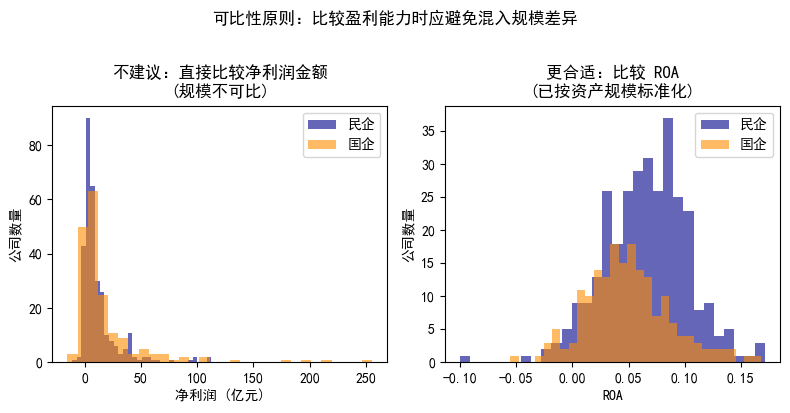

In [49]:
# ── 可比性演示：绝对金额与比率 ────────────────────────────────
# 问题：比较国企和民企的盈利能力时，应比较净利润金额还是 ROA？

df_fin2023 = df_fin[df_fin["year"] == 2023].copy()

# 模拟净利润 = ROA × 总资产。
df_fin2023["Assets"] = np.exp(df_fin2023["Size"])
df_fin2023["Net_Income"] = df_fin2023["ROA"] * df_fin2023["Assets"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# 不建议的比较：净利润金额。它混合了盈利能力和公司规模。
for soe_val, label, color in [(0, "民企", "darkblue"), (1, "国企", "darkorange")]:
    data = df_fin2023.loc[df_fin2023["soe"] == soe_val, "Net_Income"]

    axes[0].hist(
        data / 1e8,
        bins=30,
        alpha=0.6,
        label=label,
        color=color
    )

axes[0].set_xlabel("净利润 (亿元)")
axes[0].set_ylabel("公司数量")
axes[0].set_title("不建议：直接比较净利润金额\n(规模不可比)")
axes[0].legend()

# 更合适的比较：ROA。它把盈利能力标准化为资产收益率。
for soe_val, label, color in [(0, "民企", "darkblue"), (1, "国企", "darkorange")]:
    data = df_fin2023.loc[df_fin2023["soe"] == soe_val, "ROA"]

    axes[1].hist(
        data,
        bins=30,
        alpha=0.6,
        label=label,
        color=color
    )

axes[1].set_xlabel("ROA")
axes[1].set_ylabel("公司数量")
axes[1].set_title("更合适：比较 ROA\n(已按资产规模标准化)")
axes[1].legend()

plt.suptitle("可比性原则：比较盈利能力时应避免混入规模差异", y=1.02)
plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_comparability.png", dpi=150, bbox_inches="tight")
plt.show()


### 稳定性：结论是否依赖某个作图选择

Yu and Barter (2023) 的 PCS 框架包括 predictability、computability 和 stability。其中，**稳定性 (stability)** 指结论在合理的替代判断下是否依然成立。

在可视化中，「判断」包括：

- 直方图的 bin 宽度。
- 核密度估计的带宽。
- 是否使用对数坐标。
- 是否排除极端值。
- 时间窗口如何选择。
- 分组变量如何定义。

下面的例子检查「民企 ROA 高于国企」这一发现，是否在不同年份和不同样本定义下保持稳定。


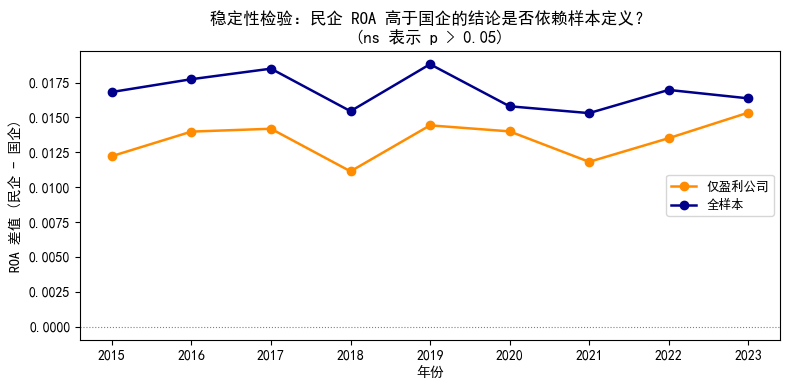

稳定性结论：
  仅盈利公司：9 年中有 9 年民企 ROA 显著高于国企。
  全样本：9 年中有 9 年民企 ROA 显著高于国企。


In [51]:
# ── 稳定性检验：国企与民企 ROA 差异 ───────────────────────────

results = []

for year in YEARS:
    base = df_fin[df_fin["year"] == year].copy()

    for include_loss in [True, False]:
        sample = base.copy()

        if not include_loss:
            sample = sample[sample["ROA"] > 0].copy()

        roa_private = sample.loc[sample["soe"] == 0, "ROA"]
        roa_soe = sample.loc[sample["soe"] == 1, "ROA"]

        diff = roa_private.mean() - roa_soe.mean()

        # Welch t-test 不要求两组方差相等，更适合教学演示。
        t_stat, p_value = stats.ttest_ind(
            roa_private,
            roa_soe,
            equal_var=False,
            nan_policy="omit"
        )

        results.append({
            "year": year,
            "sample": "全样本" if include_loss else "仅盈利公司",
            "ROA差 (民企-国企)": diff,
            "p值": p_value
        })

df_stab = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(8, 4))

for sample_type, group in df_stab.groupby("sample"):
    color = "darkblue" if sample_type == "全样本" else "darkorange"

    ax.plot(
        group["year"],
        group["ROA差 (民企-国企)"],
        marker="o",
        color=color,
        lw=1.8,
        label=sample_type
    )

    # 对 p 值大于 0.05 的年份做文字标记。
    not_sig = group[group["p值"] > 0.05]

    for _, row in not_sig.iterrows():
        ax.text(
            row["year"],
            row["ROA差 (民企-国企)"] + 0.002,
            "ns",
            fontsize=8,
            ha="center",
            color=color
        )

ax.axhline(0, color="gray", lw=0.8, linestyle=":")
ax.set_ylabel("ROA 差值 (民企 - 国企)")
ax.set_xlabel("年份")
ax.set_title("稳定性检验：民企 ROA 高于国企的结论是否依赖样本定义？\n(ns 表示 p > 0.05)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT}/EDA_stability_check.png", dpi=150, bbox_inches="tight")
plt.show()

print("稳定性结论：")
for sample_type, group in df_stab.groupby("sample"):
    n_sig = (group["p值"] < 0.05).sum()
    print(f"  {sample_type}：{len(YEARS)} 年中有 {n_sig} 年民企 ROA 显著高于国企。")


## 综合案例：从数据到报告级 EDA

本节把前面的技术串联成一个完整 EDA 摘要。目标不是展示所有可能的图，而是围绕少数关键问题产出一组可以放入报告的图形：

- 收益率分布是否接近正态？
- 市场波动是否具有阶段性？
- 不同行业盈利能力有何差异？
- 财务变量之间是否高度相关？
- 国企与民企盈利能力差异是否持续存在？


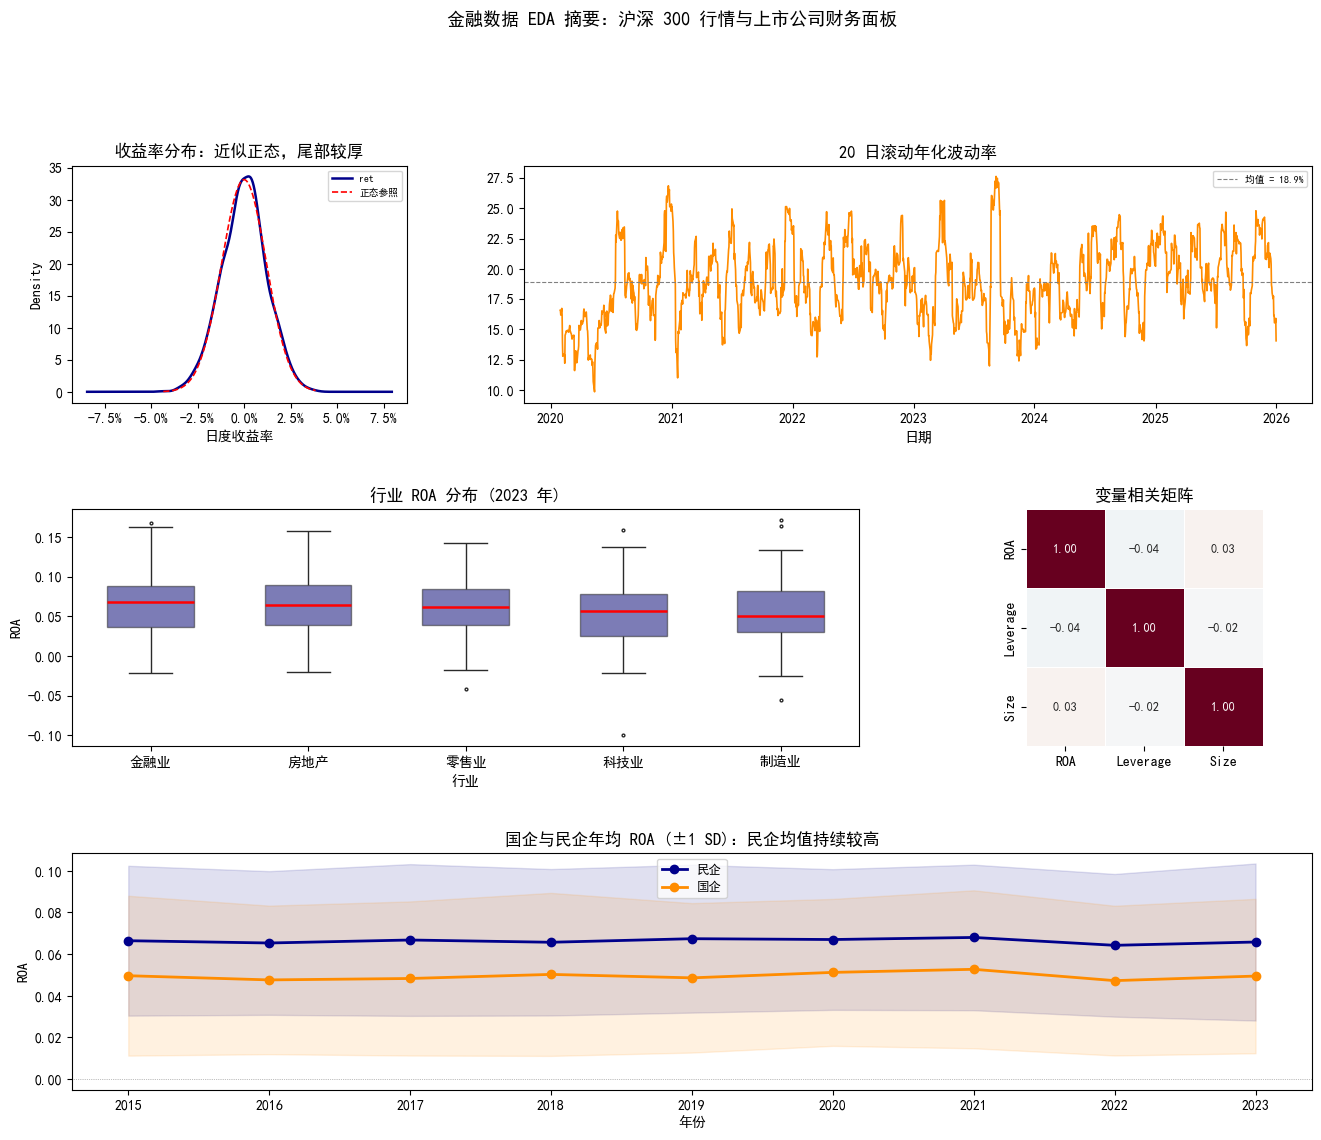

EDA 摘要图已保存至 output/EDA_eda_summary.png。


In [52]:
# ── 完整 EDA 摘要：五张图，五个问题 ───────────────────────────

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# 图形：收益率分布。
ax1 = fig.add_subplot(gs[0, 0])
hs300["ret"].plot.kde(ax=ax1, color="darkblue", lw=1.8)

x_n = np.linspace(hs300["ret"].min(), hs300["ret"].max(), 200)
ax1.plot(
    x_n,
    stats.norm.pdf(x_n, hs300["ret"].mean(), hs300["ret"].std()),
    linestyle="--",
    color="red",
    lw=1.2,
    label="正态参照"
)
ax1.set_title("收益率分布：近似正态，尾部较厚")
ax1.set_xlabel("日度收益率")
ax1.legend(fontsize=7)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=1))

# 图形：滚动年化波动率。
ax2 = fig.add_subplot(gs[0, 1:])
hs_roll_summary = hs300.copy().set_index("date")
hs_roll_summary["rv20"] = hs_roll_summary["ret"].rolling(20).std() * np.sqrt(252) * 100

ax2.plot(
    hs_roll_summary.index,
    hs_roll_summary["rv20"],
    color="darkorange",
    lw=1.2
)
ax2.axhline(
    hs_roll_summary["rv20"].mean(),
    color="gray",
    lw=0.8,
    linestyle="--",
    label=f"均值 = {hs_roll_summary['rv20'].mean():.1f}%"
)
ax2.set_title("20 日滚动年化波动率")
ax2.set_xlabel("日期")
ax2.legend(fontsize=7)

# 图形：行业 ROA 箱型图。
ax3 = fig.add_subplot(gs[1, :2])
roa23 = df_fin[df_fin["year"] == 2023].copy()

industry_order = (
    roa23
    .groupby("industry")["ROA"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)

sns.boxplot(
    data=roa23,
    x="industry",
    y="ROA",
    order=industry_order,
    color="darkblue",
    width=0.55,
    fliersize=2,
    boxprops={"alpha": 0.55},
    medianprops={"color": "red", "linewidth": 1.8},
    ax=ax3
)
ax3.set_title("行业 ROA 分布 (2023 年)")
ax3.set_xlabel("行业")
ax3.set_ylabel("ROA")

# 图形：相关热力图。
ax4 = fig.add_subplot(gs[1, 2])
corr4 = roa23[["ROA", "Leverage", "Size"]].corr()

sns.heatmap(
    corr4,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar=False,
    linewidths=0.5,
    ax=ax4,
    annot_kws={"size": 9}
)
ax4.set_title("变量相关矩阵")

# 图形：国企 vs 民企 ROA 随时间变化。
ax5 = fig.add_subplot(gs[2, :])
soe_year = (
    df_fin
    .groupby(["soe", "year"])["ROA"]
    .agg(["mean", "std"])
    .reset_index()
)

for soe_val, label, color in [(0, "民企", "darkblue"), (1, "国企", "darkorange")]:
    group = soe_year[soe_year["soe"] == soe_val]

    x_year = group["year"].to_numpy()
    y_mean = group["mean"].to_numpy()
    y_std = group["std"].to_numpy()

    ax5.plot(
        x_year,
        y_mean,
        marker="o",
        color=color,
        lw=2,
        label=label
    )
    ax5.fill_between(
        x_year,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.12,
        color=color
    )

ax5.axhline(0, color="gray", lw=0.5, linestyle=":")
ax5.set_title("国企与民企年均 ROA (±1 SD)：民企均值持续较高")
ax5.set_xlabel("年份")
ax5.set_ylabel("ROA")
ax5.legend(fontsize=9)

fig.suptitle(
    "金融数据 EDA 摘要：沪深 300 行情与上市公司财务面板",
    fontsize=13,
    y=1.01,
    fontweight="bold"
)

plt.savefig(f"{OUTPUT}/EDA_eda_summary.png", dpi=150, bbox_inches="tight")
plt.show()

print("EDA 摘要图已保存至 output/EDA_eda_summary.png。")


## 章末练习

### 判断题

- 中位数比均值对极端值更敏感，因此在金融数据中通常更常用。
- 相关系数为 0 意味着两个变量之间没有任何关系。
- 直方图的结论对 bin 宽度选择的稳定性，是 EDA 质量的一个判断依据。
- 双轴图本质上是安全的，只要两个变量的量纲不同就应该使用。
- 探索性图形和解释性图形可以使用不同图形类型表达同一个发现。

### 概念题

**练习 1 (草图到精修图)**

用本章的行业 ROA 箱型图为例，列出你会做哪些修改，把它从探索性草图转化为解释性展示图。需要写出你想传达的主题句。

**练习 2 (可比性)**

某研究者想比较 2015 年和 2023 年沪深 300 成分股的平均市值。指出至少两个可比性问题，并说明应如何解决。

**练习 3 (对数变换的适用条件)**

解释为什么对公司总资产取对数以后，和 ROA 的散点图比原始量纲下的散点图更有信息量。此时，相关系数应在原始变量还是对数变量上计算？为什么？

### 数学题

**练习 4**

给定以下 8 家公司的 ROA 数据：

`[0.03, 0.07, 0.02, -0.01, 0.12, 0.05, 0.08, 0.04]`

- 手动计算均值、中位数、方差、标准差和 MAD。
- 加入一个 ROA = 0.85 的极端值后，重新计算这五个统计量。哪些指标发生明显变化？哪些指标相对稳定？

**练习 5**

两只基金的日度收益率如下：

- 基金 A：均值 = 0.05%，标准差 = 1.2%。
- 基金 B：均值 = 0.08%，标准差 = 2.0%。

请回答：

- 计算两只基金的夏普比率，即均值除以标准差。哪只基金风险调整后的表现更好？
- 如果两只基金的日度收益率相关系数为 0.3，计算等权组合 (50% A + 50% B) 的日度收益率均值和标准差。

提示：

$$\operatorname{SD}(0.5A+0.5B)=0.5\sqrt{\operatorname{SD}^{2}(A)+\operatorname{SD}^{2}(B)+2\times0.3\times\operatorname{SD}(A)\operatorname{SD}(B)}$$

### 编程题

**练习 6 (问题驱动的 EDA)**

针对 `df_fin` 财务面板，依次回答以下三个问题。每个问题对应一张精修图，要求有主题句、坐标轴标签，并保存到 `output/` 文件夹。

- 全样本期间 (2015-2023)，哪个行业的 ROA 增长最快？
- 高杠杆公司 (`Leverage > 0.6`) 和低杠杆公司的 ROA 分布有何差异？
- 国企和民企的规模 (`Size`) 分布是否有显著差异？

**练习 7 (可视化稳定性检验)**

重复本章的「国企 vs 民企 ROA 差异」稳定性检验，额外增加两种样本划分方式：

- 只保留规模前 50% 的公司。
- 只保留制造业公司。

比较不同样本划分下的结论，讨论哪种划分更能代表「典型上市公司」。

**练习 8 (Plotly 交互图)**

用 Plotly 重新制作「各行业年均 ROA 走势」图。要求点击图例可以单独显示或隐藏某个行业，悬停时显示该年该行业的样本量、ROA 均值和 ROA 标准差。

### EDA 项目

用前面章节获取的沪深 300 历史收益率数据和 FRED 联邦基金利率数据，完成一份 EDA 报告，并整理为 Quarto 文档 `report.qmd`。

报告至少包含以下内容：

- **单变量分析**：绘制沪深 300 日度收益率的直方图和箱型图，报告均值、中位数、标准差和超额峰度，并检验三种 bin 宽度下的结论稳定性。
- **时序分析**：绘制沪深 300 净值走势图和 20 日滚动年化波动率，识别高波动时期，并查找对应的宏观背景。
- **两变量关系**：计算沪深 300 日度收益率与联邦基金利率月度变化的相关系数，绘制月度散点图，并讨论是否存在线性关系。
- **解释性图形**：从上述分析中选出一个最有意思的发现，制作一张精修图，并附上 1-2 句主题句说明结论。

提交形式：GitHub 仓库。仓库应包含 `report.qmd`、数据获取代码、清洗代码、`output/` 中的图形文件，以及必要的运行说明。


## 参考文献

- Healy, K. (2019). *Data visualization: A practical introduction*. Princeton University Press. [Link](https://socviz.co), [Google](<https://scholar.google.com/scholar?q=Data+Visualization+A+Practical+Introduction+Kieran+Healy>).

- Knaflic, C. N. (2015). *Storytelling with data: A data visualization guide for business professionals*. John Wiley & Sons. [Link](https://www.storytellingwithdata.com/books), [Google](<https://scholar.google.com/scholar?q=Storytelling+with+Data+A+Data+Visualization+Guide+for+Business+Professionals>).

- Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley. [Google](<https://scholar.google.com/scholar?q=John+Tukey+Exploratory+Data+Analysis+1977>).

- Wilke, C. O. (2019). *Fundamentals of data visualization*. O'Reilly Media. [Link](https://clauswilke.com/dataviz), [Google](<https://scholar.google.com/scholar?q=Fundamentals+of+Data+Visualization+Claus+Wilke>).

- Yu, B., & Barter, R. L. (2023). *Veridical data science: The practice of responsible data analysis and decision making*. MIT Press. [Link](https://vdsbook.com), [Google](<https://scholar.google.com/scholar?q=Veridical+Data+Science+Bin+Yu+Rebecca+Barter>).
